In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import mygene
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from numpy import absolute
from sklearn.impute import SimpleImputer
import shap
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse
import lightgbm
from lightgbm import LGBMRegressor, early_stopping
import catboost as cb
from catboost import CatBoostRegressor
from sklearn.metrics import accuracy_score

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme(
    style="ticks",
    rc={"axes.spines.top": False, "axes.spines.right": False}
)
sns.set_context('paper')  # or 'talk', 'notebook', 'poster'
custom_palette = [
    "#b3cde3",  # pastel blue (like Peakachu)
    "#8da0cb",  # mid blue (like Mustache)
    "#a6bddb",  # muted blue
    "#bebada",  # blue-lavender
    "#7b8ed9",  # strong blue
    "#5e6ec8",  # deep blue-purple (like Cooltools)
]
sns.set_palette(custom_palette)


In [3]:
merged = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/loops_with_gene_info.cleaned.csv")
merged

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,loop_chr,loop_start,loop_end,gene_id
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004..."
1,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,0.038743,...,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,chr1,9782500,9867500,"ENST00000361311.4,ENST00000377298.9,ENST000006..."
2,71,chr1,21222500,21227500,chr1,21572500,21577500,shared,0.015427,0.010033,...,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,chr1,21222500,21577500,"ENST00000264205.10,ENST00000357071.8,ENST00000..."
3,77,chr1,22665000,22670000,chr1,22960000,22965000,shared,0.025278,0.027536,...,0.587471,0.558545,0.492335,0.536689,-0.028926,0.044354,chr1,22665000,22965000,"ENST00000374627.1,ENST00000374630.8,ENST000003..."
4,78,chr1,22672500,22677500,chr1,22882500,22887500,shared,0.019734,0.030242,...,0.587471,0.558545,0.661385,0.647487,-0.028926,-0.013898,chr1,22672500,22887500,"ENST00000374627.1,ENST00000374630.8,ENST000003..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,32165,chr7,51412500,51417500,chr7,55602500,55607500,gained,0.021059,0.011941,...,0.406646,0.454487,0.610640,0.678323,0.047841,0.067683,chr7,51412500,55607500,"ENST00000275493.7,ENST00000342916.7,ENST000003..."
1246,32208,chr8,94812500,94817500,chr8,95022500,95027500,gained,0.012306,0.015876,...,0.040931,0.090414,0.528279,0.409177,0.049483,-0.119102,chr8,94812500,95027500,"ENST00000308108.9,ENST00000396133.7,ENST000005..."
1247,32213,chr8,122735000,122740000,chr8,123060000,123065000,gained,0.005878,0.011803,...,0.580906,0.531595,-0.156556,-0.213083,-0.049312,-0.056527,chr8,122735000,123065000,"ENST00000314393.6,ENST00000521482.5,ENST000005..."
1248,32230,chr9,33582500,33587500,chr9,38552500,38557500,gained,0.040927,0.032843,...,-0.120256,-0.077855,0.011444,-0.040473,0.042401,-0.051918,chr9,33582500,38557500,"ENST00000329305.6,ENST00000378292.9,ENST000004..."


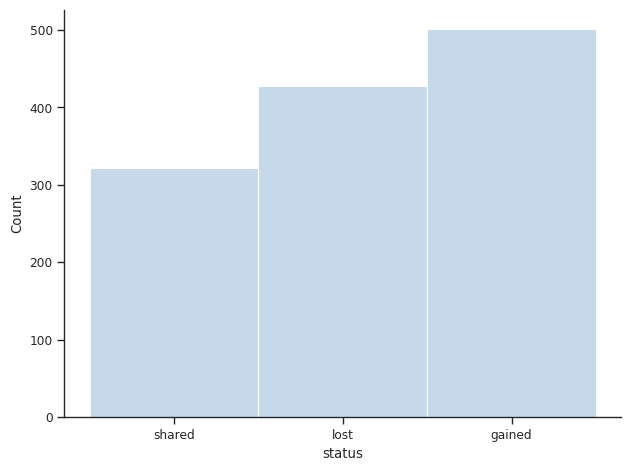

In [4]:
ax = sns.histplot(
    data=merged,
    x="status", 
)
plt.tight_layout()
plt.show()

In [1]:
# FacetGrid for multi-category subplots

g = sns.FacetGrid(merged, col="status")
g.map_dataframe(
    sns.histplot,
    x="log2FC"
)
g.set_axis_labels("log2fc", "counts")
plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

In [6]:
merged[merged["status"] == "shared"]

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,loop_chr,loop_start,loop_end,gene_id
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004..."
1,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,0.038743,...,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,chr1,9782500,9867500,"ENST00000361311.4,ENST00000377298.9,ENST000006..."
2,71,chr1,21222500,21227500,chr1,21572500,21577500,shared,0.015427,0.010033,...,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,chr1,21222500,21577500,"ENST00000264205.10,ENST00000357071.8,ENST00000..."
3,77,chr1,22665000,22670000,chr1,22960000,22965000,shared,0.025278,0.027536,...,0.587471,0.558545,0.492335,0.536689,-0.028926,0.044354,chr1,22665000,22965000,"ENST00000374627.1,ENST00000374630.8,ENST000003..."
4,78,chr1,22672500,22677500,chr1,22882500,22887500,shared,0.019734,0.030242,...,0.587471,0.558545,0.661385,0.647487,-0.028926,-0.013898,chr1,22672500,22887500,"ENST00000374627.1,ENST00000374630.8,ENST000003..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,7360,chrX,37742500,37747500,chrX,38172500,38177500,shared,0.012702,0.022512,...,1.073586,1.025712,0.865611,0.950734,-0.047874,0.085123,chrX,37742500,38177500,"ENST00000378533.4,ENST00000432886.6,ENST000004..."
317,7377,chrX,51622500,51627500,chrX,52242500,52247500,shared,0.005325,0.005295,...,0.814139,0.637226,0.938958,0.917371,-0.176914,-0.021587,chrX,51622500,52247500,"ENST00000326587.12,ENST00000375695.2,ENST00000..."
318,7400,chrX,74380000,74385000,chrX,74455000,74460000,shared,0.036933,0.033289,...,0.894791,0.810972,0.924790,0.834357,-0.083820,-0.090433,chrX,74380000,74460000,"ENST00000587091.6,ENST00000636771.1"
319,7401,chrX,74385000,74390000,chrX,74540000,74545000,shared,0.016460,0.016594,...,0.924790,0.834357,0.619460,0.637803,-0.090433,0.018342,chrX,74385000,74545000,"ENST00000587091.6,ENST00000590447.1,ENST000006..."


In [7]:
# here I need log2fc(eed/control) & log2fc(DESeq2)
## question is how chromatin features of a loop affect gene expression

In [8]:
upreg_deseq=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_deseq.txt", sep="\t")
downreg_deseq=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_deseq.txt", sep="\t")
all=pd.concat([upreg_deseq, downreg_deseq])
display(all)

,ensembl_id,ensembl,log2FC,hgnc_symbol
0,ENSG00000005339,ENSG00000005339.15,0.653104,CREBBP
1,ENSG00000010292,ENSG00000010292.13,0.711214,NCAPD2
2,ENSG00000011347,ENSG00000011347.10,0.696552,SYT7
3,ENSG00000013288,ENSG00000013288.9,0.703644,MAN2B2
4,ENSG00000026508,ENSG00000026508.21,0.749793,CD44
...,...,...,...,...
77,ENSG00000290076,ENSG00000290076.1,-0.690556,ENSG00000290076
78,ENSG00000290548,ENSG00000290548.2,-0.628500,ENSG00000290548
79,ENSG00000291100,ENSG00000291100.2,-0.647279,ENSG00000291100
80,ENSG00000291117,ENSG00000291117.2,-0.658197,ENSG00000291117


In [9]:
# using pandas.explode() for each gene. To get a single row for each gene
# convert into a list ## The gene id col. is now a list
merged["gene_list"]=merged["gene_id"].str.split(',')
# creating a new row for each gene in the df
new_merged = merged.explode('gene_list')
new_merged

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,loop_chr,loop_start,loop_end,gene_id,gene_list
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000377939.5
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000463453.1
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000466994.5
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000483336.1
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000484435.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,0.693939,0.805269,0.697137,-0.104023,-0.108131,chr9,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000297814.7
1249,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,0.693939,0.805269,0.697137,-0.104023,-0.108131,chr9,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000334204.6
1249,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,0.693939,0.805269,0.697137,-0.104023,-0.108131,chr9,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000376347.1
1249,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,0.693939,0.805269,0.697137,-0.104023,-0.108131,chr9,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000413982.5


In [10]:
mg = mygene.MyGeneInfo()

# Remove version suffix from ENSTs
new_merged['gene_list_stripped'] = new_merged['gene_list'].str.split('.').str[0]

# Get unique IDs
enst_ids = new_merged['gene_list_stripped'].dropna().unique().tolist()

# Query mygene
results = mg.querymany(enst_ids, scopes='ensembl.transcript', fields='ensembl.gene', species='human')

# Parse results
mapping = []
for item in results:
    enst = item.get('query')
    if 'ensembl' in item:
        ens_field = item['ensembl']
        if isinstance(ens_field, dict):
            ensg = ens_field.get('gene')
        elif isinstance(ens_field, list) and len(ens_field) > 0:
            ensg = ens_field[0].get('gene')
        else:
            ensg = None
        if ensg:
            mapping.append((enst, ensg))

map_df = pd.DataFrame(mapping, columns=['gene_list_stripped', 'ensembl_gene_id'])

# Merge using stripped ID
new_merged = new_merged.merge(map_df, on='gene_list_stripped', how='left')


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


1 input query terms found no hit:	['ENST00000316528']


In [11]:
new_merged = new_merged.rename(columns={'ensembl_gene_id_y': 'ensembl_gene_id'})
mapped = new_merged.dropna(subset=['ensembl_gene_id'])

In [12]:
new_merged

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,loop_chr,loop_start,loop_end,gene_id,gene_list,gene_list_stripped,ensembl_gene_id
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000377939.5,ENST00000377939,ENSG00000158286
1,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000463453.1,ENST00000463453,ENSG00000158286
2,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000466994.5,ENST00000466994,ENSG00000158286
3,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000483336.1,ENST00000483336,ENSG00000158286
4,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000484435.1,ENST00000484435,ENSG00000158286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10278,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,0.697137,-0.104023,-0.108131,chr9,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000297814.7,ENST00000297814,ENSG00000165115
10279,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,0.697137,-0.104023,-0.108131,chr9,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000334204.6,ENST00000334204,ENSG00000165115
10280,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,0.697137,-0.104023,-0.108131,chr9,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000376347.1,ENST00000376347,ENSG00000165115
10281,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,0.697137,-0.104023,-0.108131,chr9,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000413982.5,ENST00000413982,ENSG00000165115


In [13]:
# pandas merge
all_merged=new_merged.merge(
    all,
    left_on='ensembl_gene_id',
    right_on='ensembl_id',
    how='left'
)
all_merged

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,loop_start,loop_end,gene_id,gene_list,gene_list_stripped,ensembl_gene_id,ensembl_id,ensembl,log2FC_y,hgnc_symbol
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000377939.5,ENST00000377939,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
1,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000463453.1,ENST00000463453,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
2,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000466994.5,ENST00000466994,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
3,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000483336.1,ENST00000483336,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
4,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000484435.1,ENST00000484435,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10278,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000297814.7,ENST00000297814,ENSG00000165115,ENSG00000165115,ENSG00000165115.15,-0.629224,KIF27
10279,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000334204.6,ENST00000334204,ENSG00000165115,ENSG00000165115,ENSG00000165115.15,-0.629224,KIF27
10280,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000376347.1,ENST00000376347,ENSG00000165115,ENSG00000165115,ENSG00000165115.15,-0.629224,KIF27
10281,32235,chr9,83842500,83847500,chr9,84262500,84267500,gained,0.008119,0.014589,...,83842500,84267500,"ENST00000297814.7,ENST00000334204.6,ENST000003...",ENST00000413982.5,ENST00000413982,ENSG00000165115,ENSG00000165115,ENSG00000165115.15,-0.629224,KIF27


In [14]:
all_merged.columns

Index(['Unnamed: 0', 'chr1', 'start1', 'end1', 'chr2', 'start2', 'end2',
       'status', 'ctrl_signal', 'rbp1_signal', 'log2FC_x', 'log2FC_clipped',
       'condition', 'distance', 'loop_id', 'comp_switch_A1', 'comp_switch_A2',
       'loop_class', 'source', 'CTCF_signal', 'H3K27me3_signal',
       'H3K4me3_signal', 'rad21_signal', 'GC_mean', 'GC_diff',
       'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'E1_anchor2_ctrl',
       'E1_anchor2_rbp1', 'delta_E1_anchor1', 'delta_E1_anchor2', 'loop_chr',
       'loop_start', 'loop_end', 'gene_id', 'gene_list', 'gene_list_stripped',
       'ensembl_gene_id', 'ensembl_id', 'ensembl', 'log2FC_y', 'hgnc_symbol'],
      dtype='object')

In [15]:
## all_set

In [16]:
# first plotting a regression line

In [17]:
# dropna in the df
all_merged=all_merged.dropna(subset=["log2FC_x", "log2FC_y"])

In [18]:
# subset only shared loops
all_merged=all_merged[all_merged["status"] == "shared"]

In [19]:
# remove extreme outlier
all_merged = all_merged[all_merged["log2FC_x"] < 5]

In [20]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
all_merged[:10]

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC_x,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2,loop_class,source,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,loop_chr,loop_start,loop_end,gene_id,gene_list,gene_list_stripped,ensembl_gene_id,ensembl_id,ensembl,log2FC_y,hgnc_symbol
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000377939.5,ENST00000377939,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
1,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000463453.1,ENST00000463453,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
2,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000466994.5,ENST00000466994,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
3,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000483336.1,ENST00000483336,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
4,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000484435.1,ENST00000484435,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
5,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000485539.5,ENST00000485539,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
6,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000492476.1,ENST00000492476,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
7,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000496329.1,ENST00000496329,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
8,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000496676.5,ENST00000496676,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207
9,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,0.038743,-0.342747,-0.342747,shared,80000,29,stable,stable,inter-TAD,ctrl,10

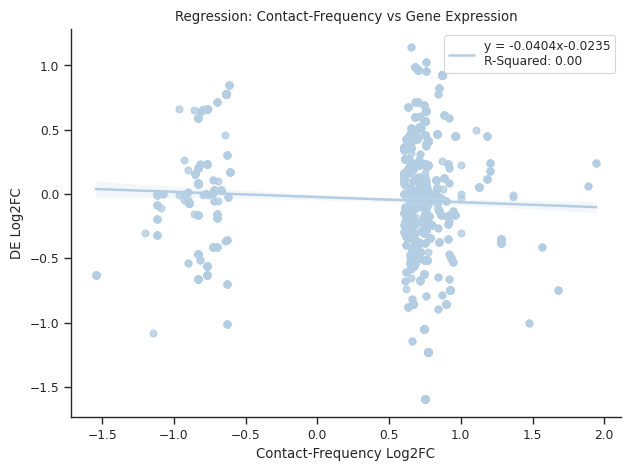

In [21]:
x = all_merged.loc[:, ["log2FC_y"]]
y = all_merged.loc[:, "log2FC_x"]

model = LinearRegression()
model.fit(x, y)

r_squared = f"R-Squared: {model.score(x, y):.2f}"
best_fit = (
    f"y = {model.coef_[0]:.4f}x"
    f"{model.intercept_:+.4f}"
)

ax = sns.regplot(
    data=all_merged,
    x="log2FC_y",
    y="log2FC_x",
    line_kws={"label": f"{best_fit}\n{r_squared}"}
)

ax.set_xlabel("Contact-Frequency Log2FC")
ax.set_ylabel("DE Log2FC")
ax.set_title("Regression: Contact-Frequency vs Gene Expression")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import r2_score
print(r2_score(y, model.predict(x)))

0.0024484928647675597


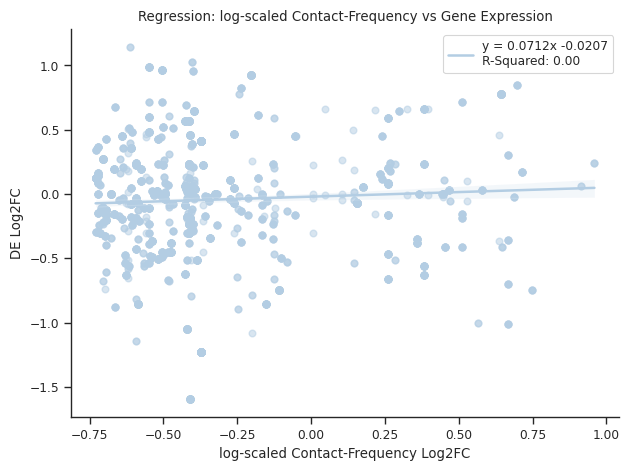

In [23]:
# Step 1: Log-transform contact frequency (preserving sign)
all_merged["log_signed_contactFC"] = np.sign(all_merged["log2FC_y"]) * np.log2(all_merged["log2FC_y"].abs() + 1e-3)

# Step 2: Drop NaNs
df = all_merged.dropna(subset=["log_signed_contactFC", "log2FC_x"])

# Step 3: Define x and y
x = df[["log_signed_contactFC"]]
y = df["log2FC_x"]

# Step 4: Fit linear model
model = LinearRegression()
model.fit(x, y)

# Step 5: Extract stats
r_squared = f"R-Squared: {model.score(x, y):.2f}"
best_fit = f"y = {model.coef_[0]:.4f}x {model.intercept_:+.4f}"

# Step 6: Plot
ax = sns.regplot(
    data=df,
    x="log_signed_contactFC",
    y="log2FC_x",
    line_kws={"label": f"{best_fit}\n{r_squared}"},
    scatter_kws={"alpha": 0.5}
)

ax.set_xlabel("log-scaled Contact-Frequency Log2FC")
ax.set_ylabel("DE Log2FC")
ax.set_title("Regression: log-scaled Contact-Frequency vs Gene Expression")
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
print(r2_score(y, model.predict(x)))

0.0029085893443071553


R² = 0.0574
Coefficients:
  log_signed_contactFC: 0.0532
  H3K27me3_signal: -0.0216
  CTCF_signal: -0.0031
  rad21_signal: -0.4040
  delta_E1_anchor1: -1.0223
  delta_E1_anchor2: -0.2824
  loopclass_shared: 0.0000
Intercept: 0.0525


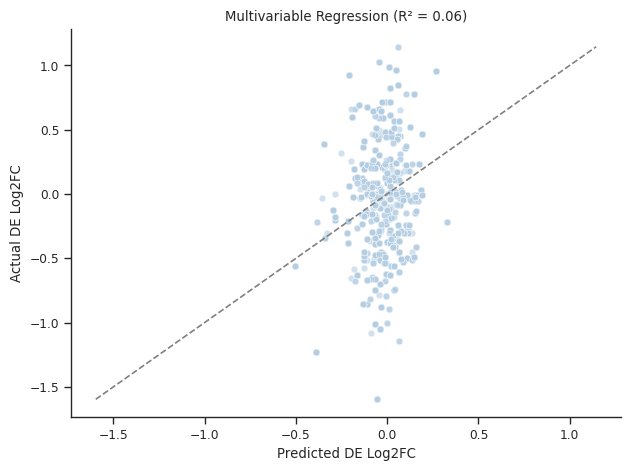

In [25]:
### multivariate

# Step 1: Select relevant features
feature_cols = [
    "log_signed_contactFC",     # transformed contact frequency
    "H3K27me3_signal",
    "CTCF_signal",
    "rad21_signal",
    "delta_E1_anchor1",
    "delta_E1_anchor2",
    "status"  # categorical (shared/gained/lost)
]

target_col = "log2FC_x"  # DE expression

# Step 2: Drop rows with missing values in selected columns
df = all_merged[feature_cols + [target_col]].dropna()

# Step 3: One-hot encode 'status'
status_encoded = pd.get_dummies(df["status"], prefix="loopclass")
df = pd.concat([df.drop(columns="status"), status_encoded], axis=1)

# Step 4: Define X and y
X = df.drop(columns=target_col)
y = df[target_col]

# Step 5: Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 6: Evaluate
r2 = r2_score(y, y_pred)
print(f"R² = {r2:.4f}")
print("Coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Step 7: Plot predicted vs actual
sns.scatterplot(x=y_pred, y=y, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='gray')
plt.xlabel("Predicted DE Log2FC")
plt.ylabel("Actual DE Log2FC")
plt.title(f"Multivariable Regression (R² = {r2:.2f})")
plt.tight_layout()
plt.show()

R² = 0.0784
Coefficients:
  log_signed_contactFC: 0.0493
  H3K27me3_signal: -0.0194
  H3K4me3_signal: 0.5575
  CTCF_signal: -0.0046
  rad21_signal: 0.2001
  GC_mean: -0.3927
  GC_diff: 0.5238
  delta_E1_anchor1: -0.9471
  delta_E1_anchor2: -0.4280
  distance: 0.0000
  loop_class_intra-TAD: 0.0025
  loop_class_uncategorized: 0.0116
Intercept: 0.0348


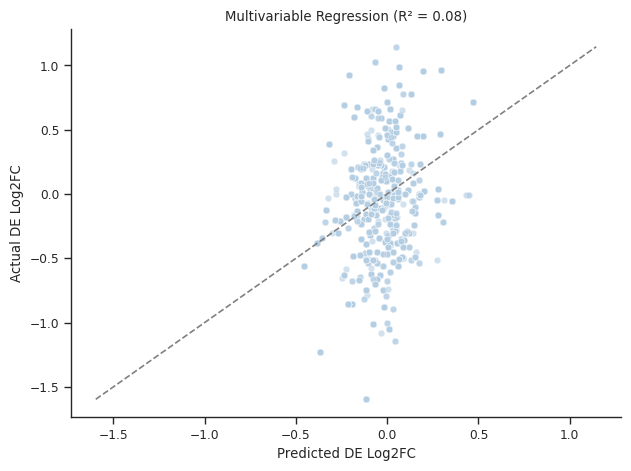

In [26]:
#### more variables than before

### Step 1: Log-transform contact frequency (preserving sign)
all_merged["log_signed_contactFC"] = (
    np.sign(all_merged["log2FC_y"]) * np.log2(all_merged["log2FC_y"].abs() + 1e-3)
)

### Step 2: One-hot encode relevant categorical features
categorical = pd.get_dummies(all_merged[["loop_class", "status"]], drop_first=True)

### Step 3: Define feature set (no compartment switch)
feature_cols = [
    "log_signed_contactFC",
    "H3K27me3_signal",
    "H3K4me3_signal",
    "CTCF_signal",
    "rad21_signal",
    "GC_mean",
    "GC_diff",
    "delta_E1_anchor1",
    "delta_E1_anchor2",
    "distance"
]

features = pd.concat([
    all_merged[feature_cols],
    categorical
], axis=1)

### Step 4: Combine with target and drop NaNs
df = pd.concat([features, all_merged["log2FC_x"]], axis=1).dropna()
X = df.drop(columns="log2FC_x")
y = df["log2FC_x"]

### Step 5: Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

### Step 6: Evaluate
r2 = r2_score(y, y_pred)
print(f"R² = {r2:.4f}")
print("Coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

### Step 7: Plot predicted vs actual
sns.scatterplot(x=y_pred, y=y, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='gray')
plt.xlabel("Predicted DE Log2FC")
plt.ylabel("Actual DE Log2FC")
plt.title(f"Multivariable Regression (R² = {r2:.2f})")
plt.tight_layout()
plt.show()

In [27]:
all_merged[:10]

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC_x,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2,loop_class,source,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,loop_chr,loop_start,loop_end,gene_id,gene_list,gene_list_stripped,ensembl_gene_id,ensembl_id,ensembl,log2FC_y,hgnc_symbol,log_signed_contactFC
0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000377939.5,ENST00000377939,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207,0.446646
1,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000463453.1,ENST00000463453,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207,0.446646
2,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000466994.5,ENST00000466994,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207,0.446646
3,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000483336.1,ENST00000483336,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207,0.446646
4,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000484435.1,ENST00000484435,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207,0.446646
5,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000485539.5,ENST00000485539,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207,0.446646
6,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000492476.1,ENST00000492476,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207,0.446646
7,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000496329.1,ENST00000496329,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207,0.446646
8,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,0.000000,0.000000,shared,135000,8,NaN,NaN,uncategorized,ctrl,15.270481,0.541482,0.855392,0.034824,0.5964,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000,"ENST00000377939.5,ENST00000463453.1,ENST000004...",ENST00000496676.5,ENST00000496676,ENSG00000158286,ENSG00000158286,ENSG00000158286.13,-0.732746,RNF207,0.446646
9,29,chr1,9782500,9787500,chr1,986250

### Non linear gradient boosting models

In [28]:
# non linear ## xgboost ### https://machinelearningmastery.com/xgboost-for-regression/

model = XGBRegressor(n_estimators=1000, max_depth=7, eta=0.1, subsample=0.7, colsample_bytree=0.8)

#========Dataprep========#

# Filter only shared loops
#shared_loops = all_merged[all_merged["status"] == "shared"].copy()

# Select relevant features
X = all_merged[[
    'ctrl_signal', 'rbp1_signal',
    #'log2FC_x',
    'loop_class',  # can encode if informative
    'CTCF_signal', 'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal',
    'GC_mean', 'GC_diff',
    'E1_anchor1_ctrl', 'E1_anchor1_rbp1',
    'E1_anchor2_ctrl', 'E1_anchor2_rbp1',
    'delta_E1_anchor1', 'delta_E1_anchor2'
]].copy()

# Add log-transformed loop distance
X["log_distance"] = np.log1p(all_merged["distance"])

# One-hot encode loop class (optional: drop if not needed)
if X['loop_class'].dtype == object or X['loop_class'].dtype.name == 'category':
    X = pd.get_dummies(X, columns=['loop_class'], dummy_na=True)

# Drop missing values
X = X.dropna()

# target var
y = all_merged.loc[X.index, "log2FC_y"]
#========Dataprep========#

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

# define model evaluation method
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
# evaluate model
scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)

# force scores to be positive
scores = absolute(scores)
print('Mean MAE: %.3f (%.3f)' % (scores.mean(), scores.std()) )

Mean MAE: 0.042 (0.009)


In [29]:
X[:10]

,ctrl_signal,rbp1_signal,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,log_distance,loop_class_inter-TAD,loop_class_intra-TAD,loop_class_uncategorized,loop_class_nan
9,0.049133,0.038743,10.147690,8.275272,0.188543,0.034904,0.511,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,11.289794,True,False,False,False
10,0.049133,0.038743,10.147690,8.275272,0.188543,0.034904,0.511,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,11.289794,True,False,False,False
11,0.049133,0.038743,10.147690,8.275272,0.188543,0.034904,0.511,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,11.289794,True,False,False,False
12,0.015427,0.010033,3.099777,0.094171,0.188543,0.039089,0.541,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,12.765691,False,True,False,False
13,0.015427,0.010033,3.099777,0.094171,0.188543,0.039089,0.541,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,12.765691,False,True,False,False
14,0.015427,0.010033,3.099777,0.094171,0.188543,0.039089,0.541,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,12.765691,False,True,False,False
15,0.015427,0.010033,3.099777,0.094171,0.188543,0.039089,0.541,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,12.765691,False,True,False,False
16,0.015427,0.010033,3.099777,0.094171,0.188543,0.039089,0.541,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,12.765691,False,True,False,False
17,0.015427,0.010033,3.099777,0.094171,0.188543,0.039089,0.541,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,12.765691,False,True,False,False
18,0.015427,0.010033,3.099777,0.094171,0.188543,0.039089,0.541,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,12.765691,False,True,False,False


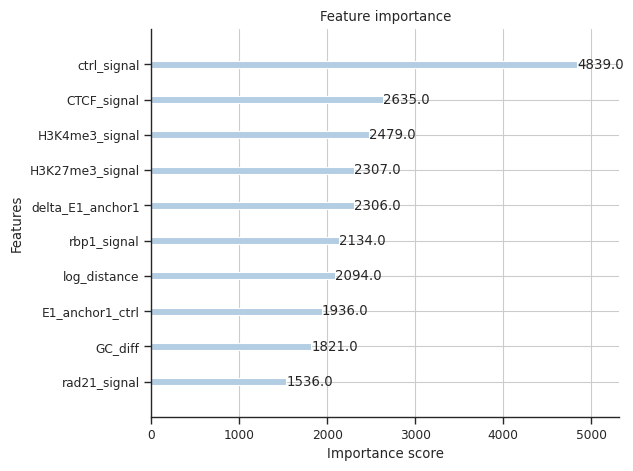

In [30]:
from xgboost import plot_importance
plot_importance(model, max_num_features=10)
plt.tight_layout()
plt.show()

In [31]:
# Fit model
model.fit(X_train, y_train)

# Predict and evaluate R²
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R² on test set: {r2:.4f}")

R² on test set: 0.8328


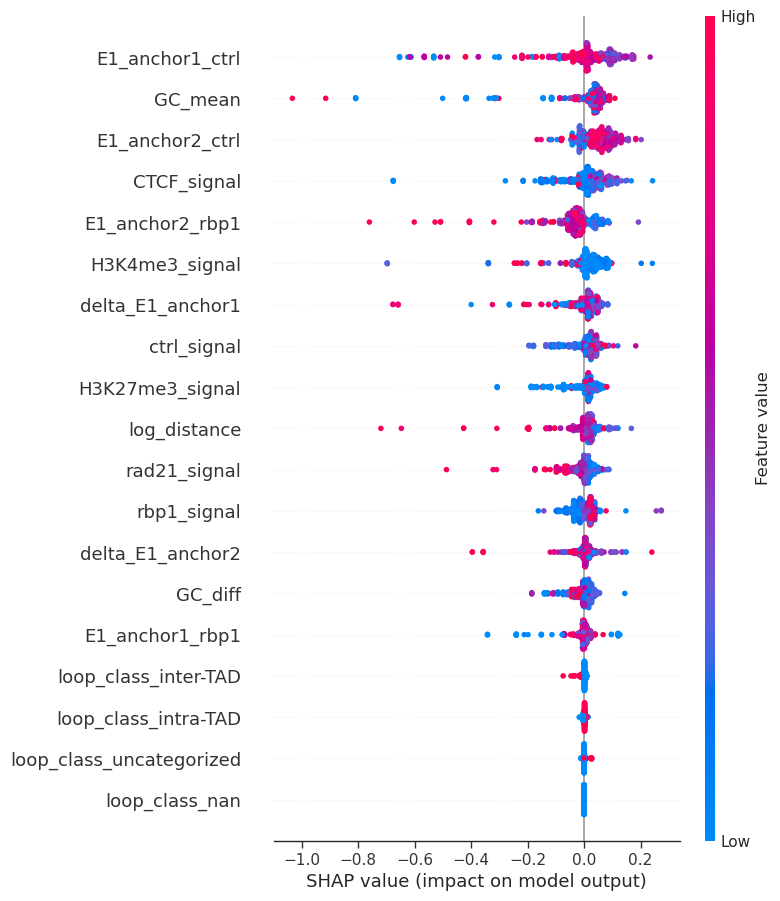

In [32]:
# model explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [33]:
## anchor1/anchor2 needs to be investigated further

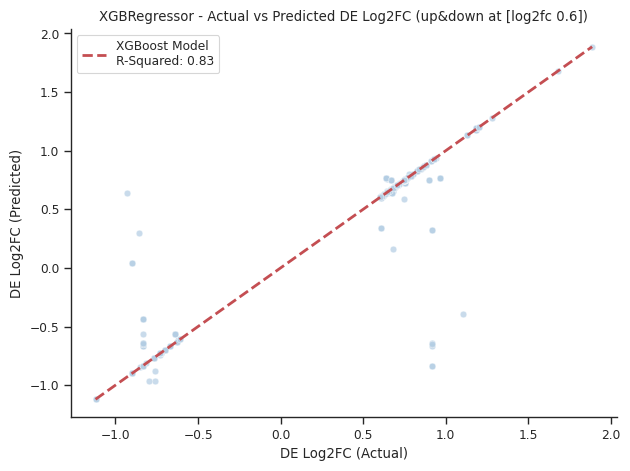

In [34]:
r_squared = f"R-Squared: {r2:.2f}"
model_info = f"XGBoost Model\n{r_squared}"


ax = sns.scatterplot(
    x=y_test, 
    y=y_pred,
    alpha=0.7
)

# Add perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label=model_info)

ax.set_xlabel("DE Log2FC (Actual)")  # y_test
ax.set_ylabel("DE Log2FC (Predicted)")  # y_pred
ax.set_title("XGBRegressor - Actual vs Predicted DE Log2FC (up&down at [log2fc 0.6])")
ax.legend()
plt.tight_layout()
plt.show()

### Lightgbm

In [35]:
# https://www.geeksforgeeks.org/machine-learning/regression-using-lightgbm/

# already defined: X_train, X_test, y_train, y_test --

# Step 1: Standardize Features
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Step 2: Create and Train the Model
model = LGBMRegressor(
    objective='regression',
    metric='rmse',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.05,
    feature_fraction=0.9,
    n_estimators=100  # maximum number of boosting rounds
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_names=['eval'],
    callbacks=[early_stopping(stopping_rounds=10)]
)

# Step 3: Predict and Evaluate
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_test)

# Store R² scores
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_test, y_val_pred)

print("Training RMSE: ", np.sqrt(mse(y_train, y_train_pred)))
print("Validation RMSE: ", np.sqrt(mse(y_test, y_val_pred)))
print("Training R²: ", r2_train)
print("Validation R²: ", r2_val)

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2746
[LightGBM] [Info] Number of data points in the train set: 1860, number of used features: 18
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Info] Start training from score 0.500952
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	eval's rmse: 0.243167
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored

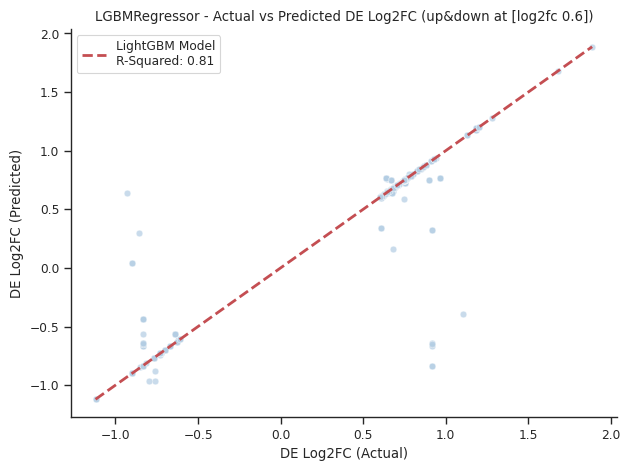

In [36]:
r_squared = f"R-Squared: {r2_val:.2f}"
model_info = f"LightGBM Model\n{r_squared}"

ax = sns.scatterplot(
    x=y_test, 
    y=y_pred,
    alpha=0.7
)

# Add perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label=model_info)

ax.set_xlabel("DE Log2FC (Actual)")  # y_test
ax.set_ylabel("DE Log2FC (Predicted)")  # y_pred
ax.set_title("LGBMRegressor - Actual vs Predicted DE Log2FC (up&down at [log2fc 0.6])")
ax.legend()
plt.tight_layout()
plt.show()

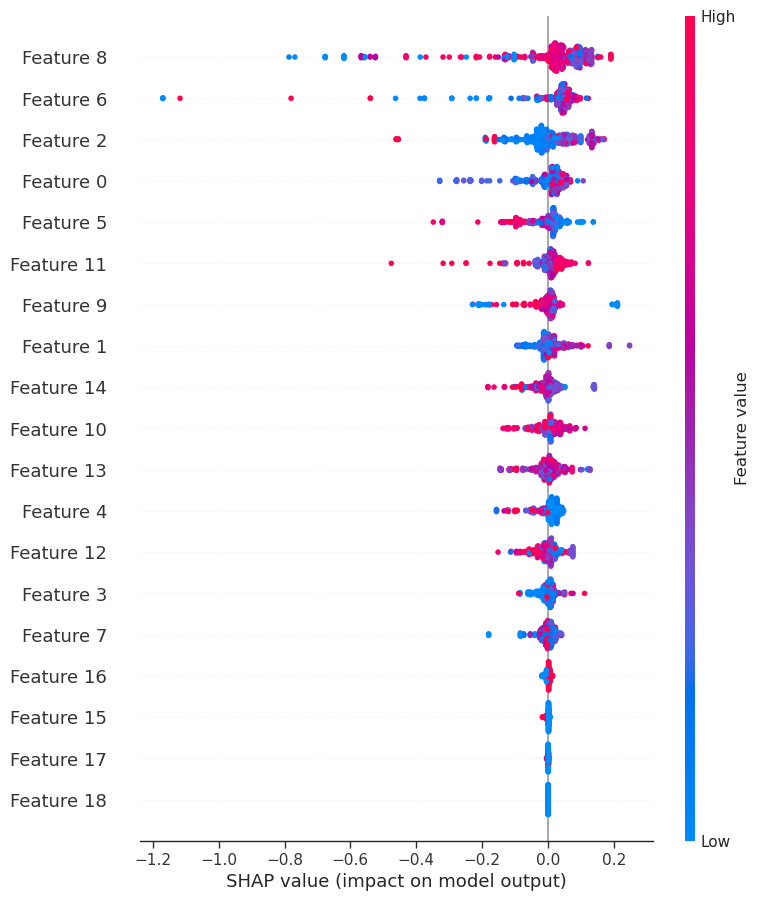

In [37]:
# model explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [38]:
print(lightgbm.__version__)


4.6.0


### Catboost

In [39]:
model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, verbose=0)
model.fit(X_train, y_train) 

In [40]:
#Make predictions
y_pred = model.predict(X_test)

# Evaluate using mean squared error (MSE)
mse = mse(y_test, y_pred)
r2_cat = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2_cat:.4f}")

Mean Squared Error: 0.05
R² Score: 0.8434


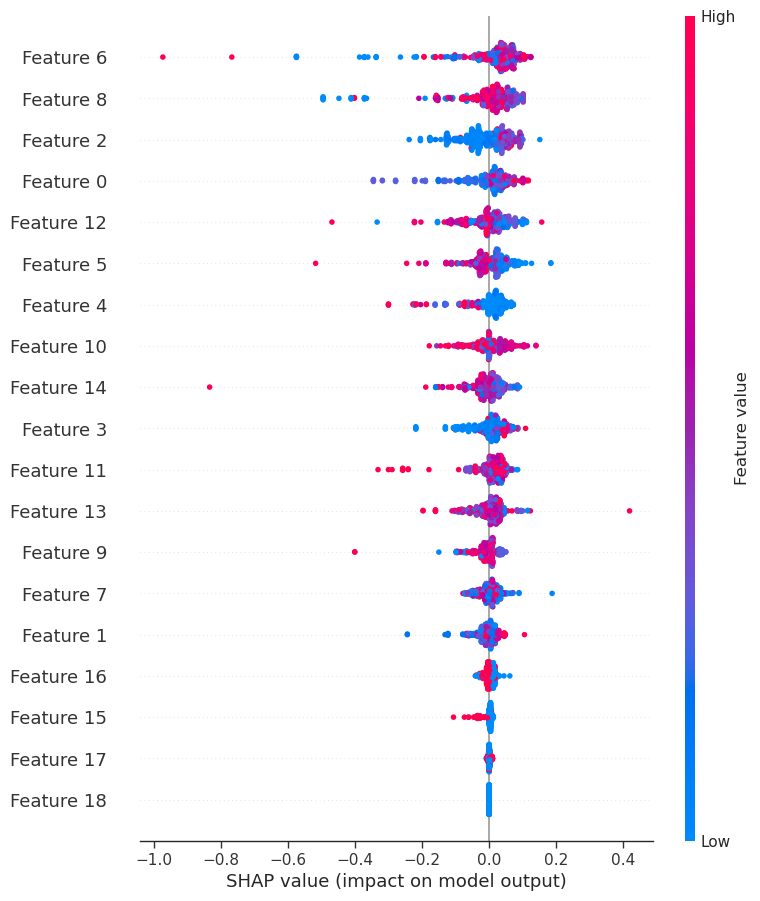

In [41]:
# model explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [42]:
print(cb.__version__)

1.2.8


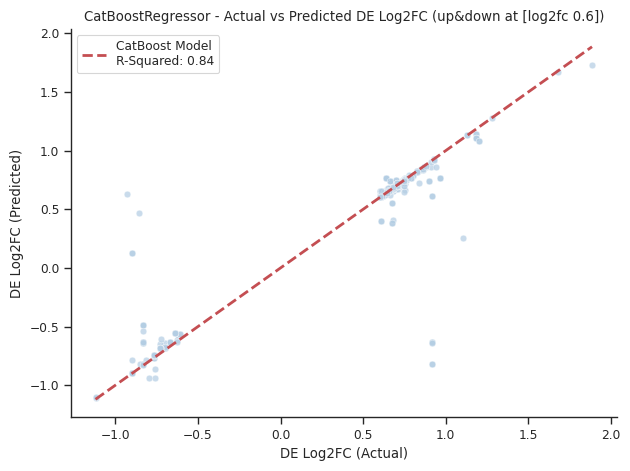

In [43]:
r_squared = f"R-Squared: {r2_cat:.2f}"
model_info = f"CatBoost Model\n{r_squared}"

ax = sns.scatterplot(
    x=y_test, 
    y=y_pred,
    alpha=0.7
)

# Add perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label=model_info)

ax.set_xlabel("DE Log2FC (Actual)")  # y_test
ax.set_ylabel("DE Log2FC (Predicted)")  # y_pred
ax.set_title("CatBoostRegressor - Actual vs Predicted DE Log2FC (up&down at [log2fc 0.6])")
ax.legend()
plt.tight_layout()
plt.show()

In [44]:
# exploratory # features vs target

In [45]:
X_train.shape

(1860, 19)

In [46]:
y_train.shape

(1860,)

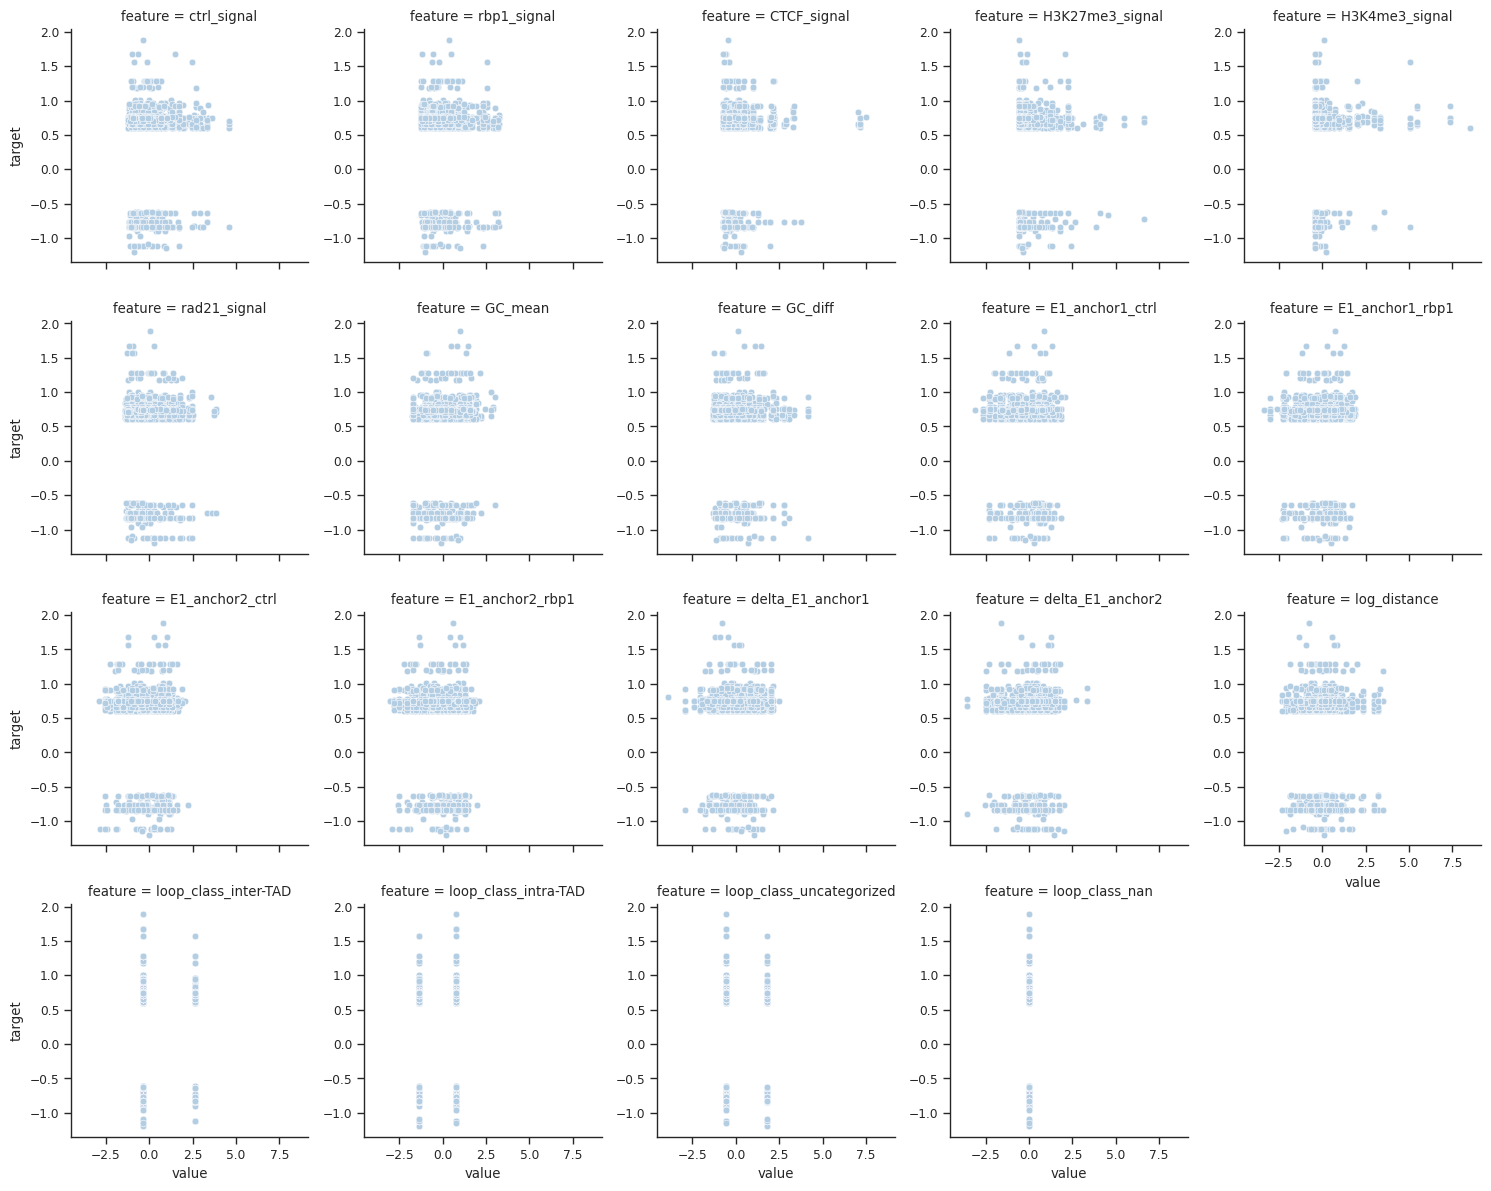

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Construct df from X_train with real feature names from X
df = pd.DataFrame(X_train, columns=X.columns)
df['target'] = y_train

# Melt for FacetGrid
df_melt = df.melt(id_vars='target', var_name='feature', value_name='value')

# FacetGrid plot
g = sns.FacetGrid(df_melt, col="feature", col_wrap=5, sharey=False)
g.map(sns.scatterplot, "value", "target")
plt.tight_layout()
plt.show()

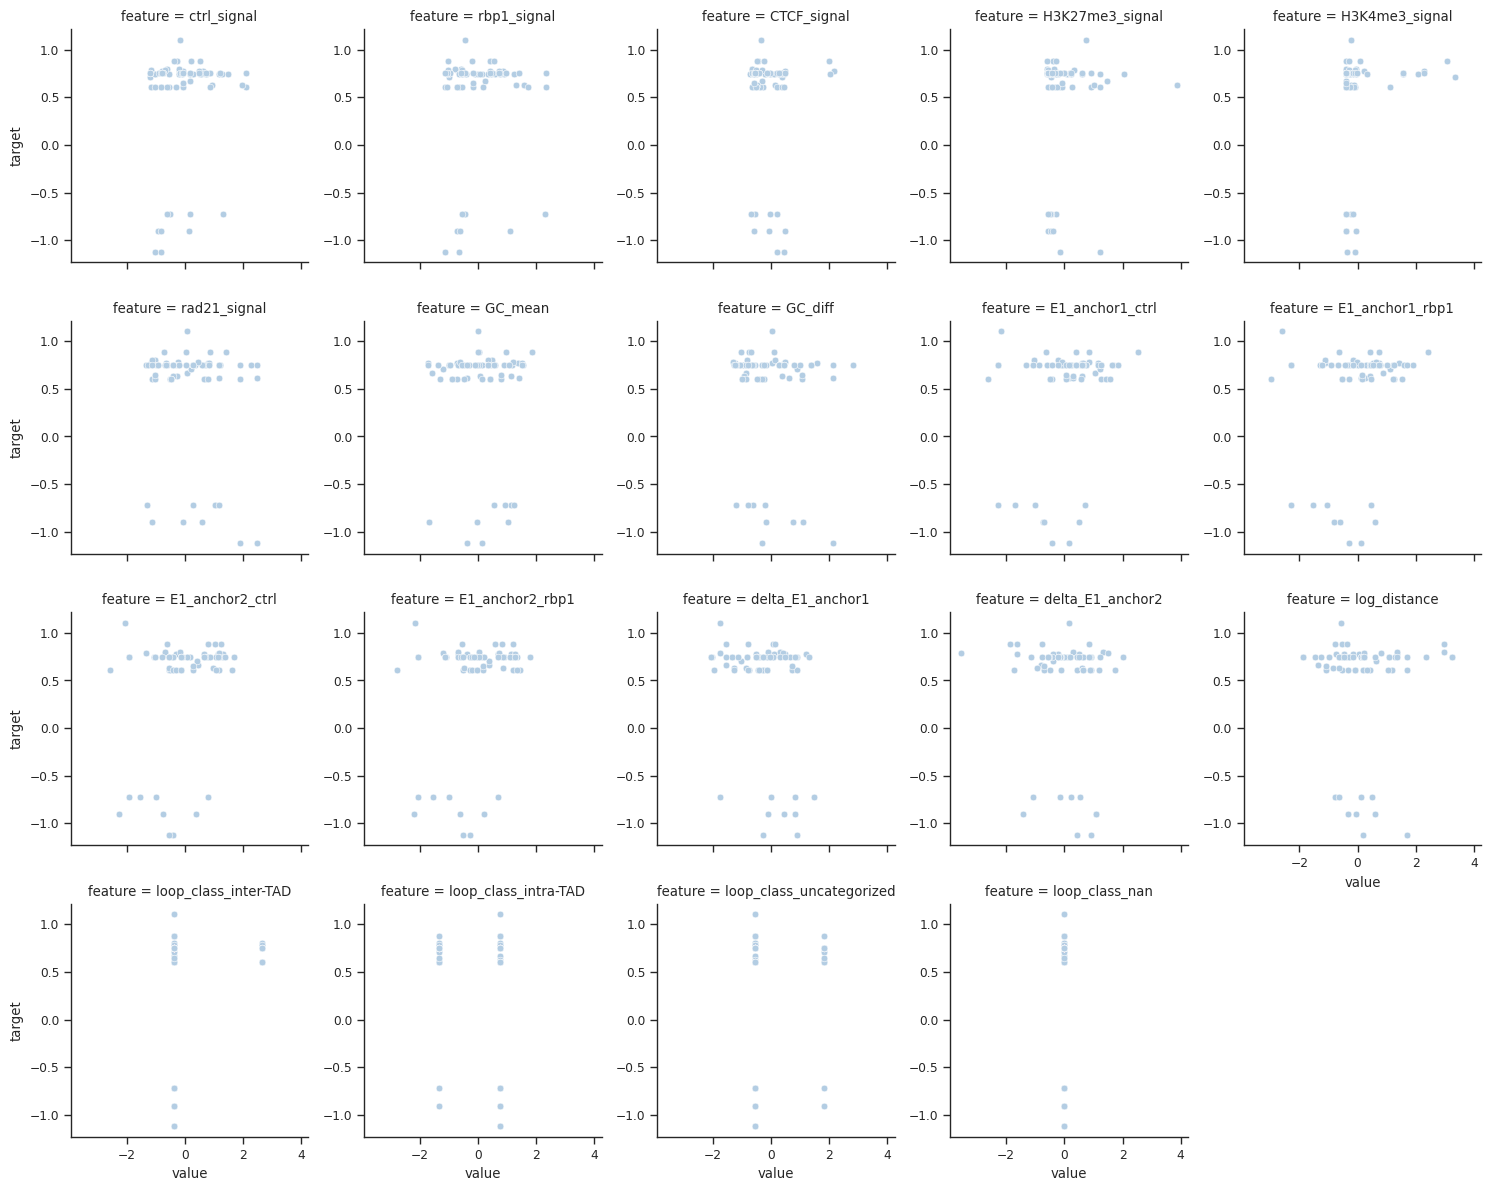

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Use original column names from X
df_test = pd.DataFrame(X_test, columns=X.columns)
df_test['target'] = y_test

# Melt for FacetGrid
df_test_melt = df_test.melt(id_vars='target', var_name='feature', value_name='value')

# Plot
g = sns.FacetGrid(df_test_melt, col="feature", col_wrap=5, sharey=False)
g.map(sns.scatterplot, "value", "target")
plt.tight_layout()
plt.show()

In [49]:
all_merged.to_csv("mlregression_alldata_df.csv", sep="\t")